# Hotel Booking Cancellation Analysis
## Project Overview

This project analyzes hotel booking data to understand the characteristics associated with booking cancellation.

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load data
df = pd.read_csv('C:/Users/USER/Desktop/Python for Data Analytis and Data Apps/Hotel Analysis/hotel_bookings.csv')

In [3]:
# dataset shape 
df.shape

(119390, 32)

##The data has 119390 rows and 32 columns

In [4]:
# dataset information to identify problems with data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [5]:
# Check for missing values
df.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [6]:
# Check for duplicates
# duplicates affect your analysis thus influencing your results
# understand in which context they exist before removing
df.duplicated().sum()

np.int64(31994)

## Data Cleaning

In [7]:
# Fill Agent and Company with 0s to mean booked directly
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)

In [8]:
# Fill the children with 0
df['children'] = df['children'].fillna(0)

In [9]:
# Changing the datatype for children from float to int
df['children'] =  df['children'].astype(int)

In [10]:
# Drop the rest of the missing values like country which you cant fill with 0 
df = df.dropna()

In [11]:
# drop duplicates
df = df.drop_duplicates()

## Validation

In [12]:
# Recheck for missing values
df.isna().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

In [13]:
# Recheck for Duplicates
df.duplicated().sum()

np.int64(0)

In [14]:
# Recheck the dataset shape
df.shape


(86944, 32)

# Feature Engineering

## Creating new features in our dataset by adding columns or rows

In [15]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,0.0,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,0.0,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [16]:
## Calculate total nights the guest stayed in the hotel
df['total_nights'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']


In [17]:
# Calculate total guests
df['total_guests'] = df['children'] + df['babies']

In [18]:
# Check whether is family (True if there are children or babies, False if otherwise)
df['is_family'] = (df['babies']>0) + (df['children']>0)

In [19]:
# Create season based on the arrival date month
month_to_season = {
    'December':'Winter', 'January':'Winter', 'February':'Winter',
    'March':'Spring', 'April':'Spring', 'May':'Spring',
    'June':'Summer', 'July':'Summer', 'August':'Summer',
    'September':'Fall', 'October':'Fall', 'November':'Fall'
}

df['season'] = df['arrival_date_month'].map(month_to_season)


In [20]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_nights,total_guests,is_family,season
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,0,0,False,Summer
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,0,0,False,Summer
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,1,0,False,Summer
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,1,0,False,Summer
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,2,0,False,Summer


In [21]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


## Exploratory Data Analysis (EDA)


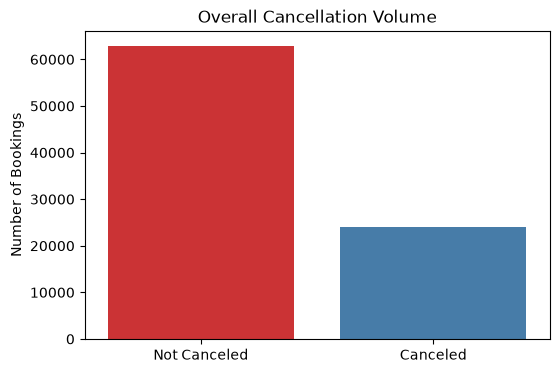

Overall Cancellation Rate: 27.6%


In [22]:
# Overall Cancellation distribution
plt.figure(figsize=(6,4))
df['is_canceled_label'] = df['is_canceled'].map({0: 'Not Canceled', 1: 'Canceled'})

sns.countplot(data=df, x='is_canceled_label', hue='is_canceled_label', palette='Set1', legend=False)
plt.title('Overall Cancellation Volume')
plt.ylabel('Number of Bookings')
plt.xlabel('')
plt.savefig('cancellation.png')
plt.show()

# Calculate the overall cancellation rate
cancel_pct = df['is_canceled'].value_counts(normalize=True) * 100
print(f'Overall Cancellation Rate: {cancel_pct[1]:.1f}%')

# Insights based on Booking and Cancellation Rate
### Out of about 87,000 total bookings, roughly 63,000 (72.4%) were honored while 24,000 (27.6%) were canceled. This shows strong demand overall, but cancellations remain significant—more than one in four reservations. Management should not rely on initial booking numbers alone when planning staffing or ordering, as cancellations can materially reduce actual occupancy.

### To safeguard revenue and ensure hotels remain full, management should adopt a controlled overbooking strategy, supported by tiered cancellation policies and incentives for non‑refundable reservations. This approach balances customer satisfaction with operational efficiency, helping the hotel maximize occupancy and avoid losses from last‑minute cancellations.

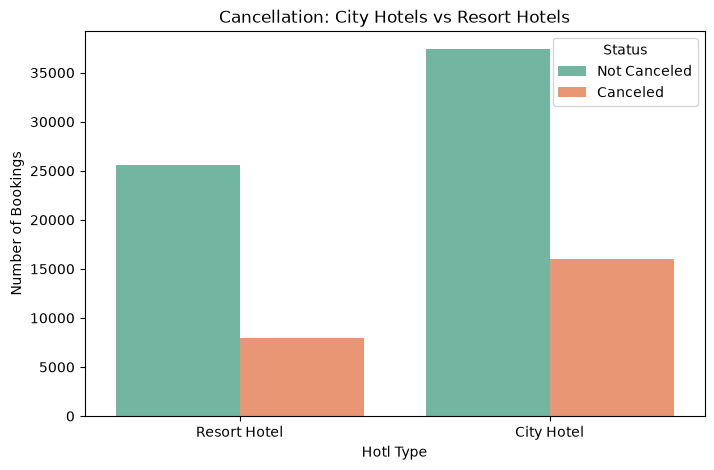

hotel         is_canceled
City Hotel    0              69.965557
              1              30.034443
Resort Hotel  0              76.296164
              1              23.703836
Name: proportion, dtype: float64

In [23]:
#Hotel Type Comparison
# Does the hotel type affect the likelihood of cancellation?
# We will compare the city hotels to resort hotels to see if their customer bases behave differently.
plt.figure(figsize=(8,5))
sns.countplot(x='hotel', hue='is_canceled_label', data=df, palette='Set2')
plt.title('Cancellation: City Hotels vs Resort Hotels')
plt.ylabel('Number of Bookings')
plt.xlabel('Hotl Type')
plt.legend(title='Status')
plt.savefig('hoteltype.png')
plt.show()

# Calculate rates per hotel type
df.groupby('hotel')['is_canceled'].value_counts(normalize=True)*100

# Booking Insights Based on Hotel Type
#### City Hotels generate far more bookings than Resort Hotels, but they also face higher cancellations. To protect revenue, management could adopt strategies like controlled overbooking, stricter cancellation policies, or offering incentives for non‑refundable reservations. These measures would help offset the risk of lost revenue while maintaining customer satisfaction.

#### Resort Hotels, though smaller in volume, show more stable bookings with fewer cancellations. Management can leverage this reliability by promoting longer‑stay packages, bundling experiences, and increasing visibility to grow demand. 

#### Together, these approaches balance high‑volume but volatile city bookings with steady resort performance.

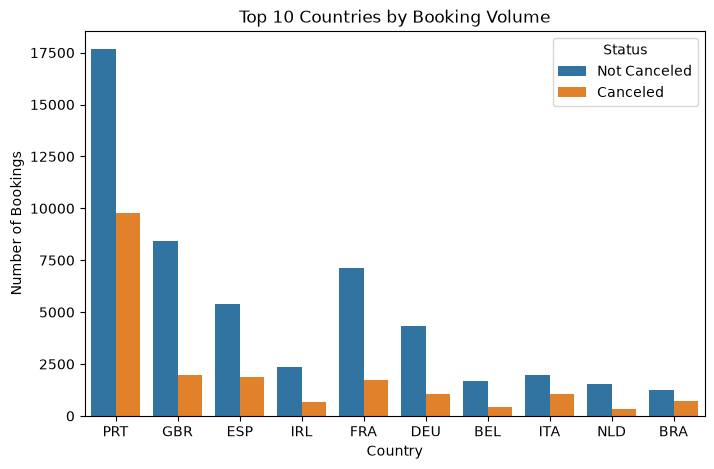

In [24]:
# Undestanding geographicla origin of our customers
plt.figure(figsize=(8,5))
# Get top 10 countries by volume
top_10_countries = df['country'].value_counts().head(10).index
sns.countplot(x='country', hue='is_canceled_label', data=df[df['country'].isin(top_10_countries)])

plt.title('Top 10 Countries by Booking Volume')
plt.ylabel('Number of Bookings')
plt.xlabel('Country')
plt.legend(title='Status')
plt.savefig('countries.png')
plt.show()

# Insights Based on Top 10 Countries

#### Portugal stands out as the largest source of bookings, but it also has the highest cancellation rate. This combination signals strong demand but also potential weaknesses in customer confidence or booking conditions. Management should treat Portugal as both an opportunity and a risk, digging deeper into why cancellations are so frequent despite high interest.

#### United Kingdom and Spain show healthy booking volumes with relatively lower cancellation rates. These markets appear more stable and predictable, making them strong candidates for continued investment, loyalty programs, and up-selling strategies. They represent reliable revenue streams that can balance the volatility seen in Portugal.

#### Smaller markets like Belgium, Italy, and the Netherlands show modest booking activity but steadier cancellation ratios, offering room for growth through targeted campaigns. Meanwhile, Germany and Brazil combine lower volumes with higher cancellations, raising red flags that warrant closer monitoring before scaling resources. This mix of signals suggests management should pursue growth selectively while addressing risks.

PRT(Portugal) generate the highest booking volume of bookings, but it also has a staggering cancellation rate. Because the hotels in this dataset are located in portugal, these are local residents. Locals often book multiple hotels as 'backups' for weekend getaways because they don't have to commit to flights.


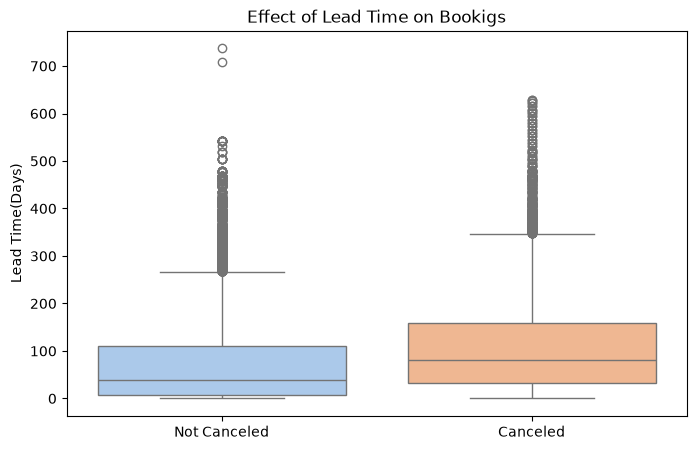

In [25]:
# Lead Time Analysis Lead time is the number of days between when the guest book and when they arrive
plt.figure(figsize=(8,5))
sns.boxplot(x='is_canceled_label', y='lead_time', data=df, hue='is_canceled_label', palette='pastel', legend=False)
plt.title('Effect of Lead Time on Bookigs')
plt.ylabel('Lead Time(Days)')
plt.xlabel('')
plt.savefig('leadtime.png')
plt.show()

The median time for canceled bookings is much higher.The earlier someone books, the more time they have to change their mind,find a better deal or experience a schedule change.

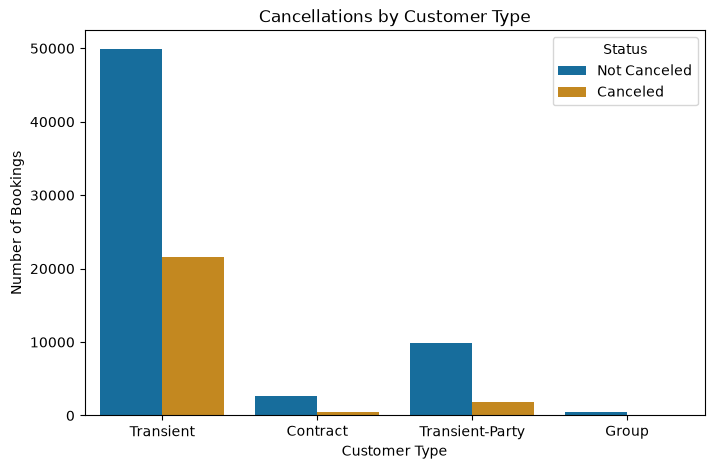

In [26]:
# Customer Type Analysis
# Are solo/transient traveller more volatile than larger groups
plt.figure(figsize=(8,5))
sns.countplot(x='customer_type', hue='is_canceled_label',data=df, palette='colorblind' )
plt.title('Cancellations by Customer Type')
plt.ylabel('Number of Bookings')
plt.xlabel('Customer Type')
plt.legend(title='Status')
plt.savefig('customertype.png')
plt.show()

'Transient' travelers (independent travelers not part of a group) account for the vast majority of both bookings and cancellations. Conversely, 'Groups' and 'Contract' bookings are much more stable. Recommendation: The sales team should prioritize securing more B2B (business-to-business) contracts and group events to build a stable, guaranteed revenue base that protects against the volatility of individual transients.

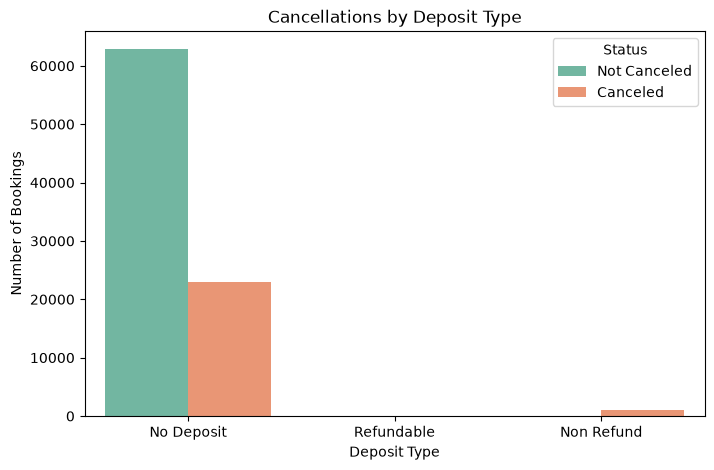

In [27]:
# Impact of deposit type on cancellations
plt.figure(figsize=(8,5))
sns.countplot(x='deposit_type', hue='is_canceled_label', data=df, palette='Set2')
plt.title('Cancellations by Deposit Type')
plt.ylabel('Number of Bookings')
plt.xlabel('Deposit Type')
plt.legend(title='Status')
plt.savefig('deposittype.png')
plt.show()

The majority of the bookings have no deposit. Management should implement a compulsory and non-refundable deposit to curb volatility in bookings and stabilize revenue.

# Seasonal Cancellation Analysis

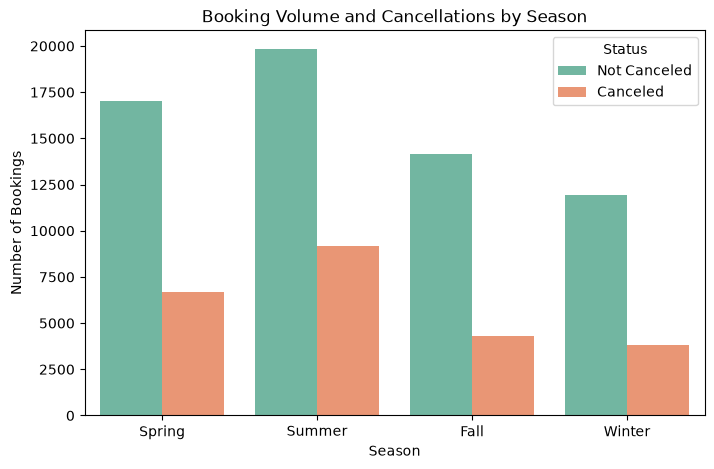

In [28]:
plt.figure(figsize=(8,5))

# Define the seasonal order
season_order = ['Spring', 'Summer', 'Fall', 'Winter']

sns.countplot(x='season', hue='is_canceled_label', data=df, order=season_order, palette='Set2')
plt.title('Booking Volume and Cancellations by Season')
plt.ylabel('Number of Bookings')
plt.xlabel('Season')
plt.legend(title='Status')
plt.savefig('seasonal.png')
plt.show()

Summer shows the highest total volume of bookings and the highest absolute number of cancellations.